# Non-Invasive Blood Glucose Estimation: Strict Zero-Leakage ML Pipeline

This notebook implements a **strict zero-leakage cross-validation pipeline** on the real PPG dataset (`glucosense_r_dataset_2026-09-04.csv`).

## Key Pipeline Improvements (Methodological Rigor):
1. **Signal Preprocessing & Feature Extraction**: Extract complete pulse wave morphological, APG derivative, time-domain, non-linear, and spectral features using `neurokit2` and custom landmark detectors.
2. **Strict Fold-Level Feature Selection (Zero Data Leakage)**: Pearson correlation ranking and multicollinearity filtering ($|r| > 0.85$) are performed **inside each cross-validation fold** using ONLY the training split (`X_train`, `y_train`). The validation fold (`X_val`, `y_val`) remains 100% unseen.
3. **Fold Feature Logging & Stability Inspection**: Every feature set selected per fold across all CV strategies is logged and analyzed for feature stability.
4. **Fold-Level Imputation**: `SimpleImputer` is fit strictly on `X_train` and applied to `X_val` to prevent test-set mean leakage.
5. **Comprehensive CV Suite**: Evaluates 7 ML models across 4 CV methods (**5-Fold KFold, 5-Fold GroupKFold, LOOCV, and LOGOCV**).

In [2]:
print("starting")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
from scipy.stats import skew, kurtosis
from scipy.interpolate import interp1d
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, GroupKFold, LeaveOneOut, LeaveOneGroupOut
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from collections import Counter
import xgboost as xgb

try:
    import catboost as cb
    has_catboost = True
except ImportError:
    has_catboost = False

try:
    import lightgbm as lgb
    has_lightgbm = True
except ImportError:
    has_lightgbm = False

# Set style for modern aesthetics
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150

csv_path = "data/real/glucosense_r_dataset_2026-09-17.csv"
sampling_rate = 50  # 50 Hz acquisition rate


starting


In [4]:
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"Dataset file not found at {csv_path}")

df = pd.read_csv(csv_path)
print(f"✓ Dataset loaded. Total records: {len(df)}")
print("\nFirst 3 rows:")
display(df.head(3))

print("\nSession kinds distribution:")
print(df['session_kind'].value_counts())

✓ Dataset loaded. Total records: 100

First 3 rows:


,session_id,created_at,participant_id,age,gender,weight_kg,height_cm,years_on_t2dm,medication,session_kind,bgl_mgdl,ppg_samples_count,ppg_data
0,fce4b7a2-b3db-4b11-81e7-9c8f8ace228d,2026-08-06T09:03:50.335985+00:00,P001,73,Female,74.0,170.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",fasting,196,3500,57994;58030;58020;58027;58013;58039;58044;5805...
1,07dc95d8-8001-417f-b139-d4faf092b371,2026-08-06T10:34:31.431381+00:00,P001,73,Female,74.0,170.0,8,"Alphabetuc+, glepid-2, sealmet, trevisa",1hr_post_prandial,269,3500,59419;59453;59470;59475;59513;59507;59529;5956...
2,2fb9eb9e-4f36-4749-bb66-78510db5dde9,2026-08-27T07:56:02.871753+00:00,P002,63,Female,79.0,172.0,21,NaN,fasting,190,3500,55490;55479;55469;55480;55473;55469;55476;5548...



Session kinds distribution:
session_kind
fasting              46
2hr_post_prandial    31
1hr_post_prandial    23
Name: count, dtype: int64


In [15]:
def determine_ac_dc_from_PPG(signal):
    """
    Replicates the paper's exact pseudocode for extracting AC and DC signals from raw PPG:
    1. midValue = mean(Signal)
    2. Track peak maxArray (systolic peaks) & minArray (diastolic troughs) across zero-crossings around midValue
    3. acSignal = mean(maxArray) - mean(minArray)
    4. dcSignal = midValue
    5. ac_dc_ratio = acSignal / dcSignal
    """
    signal = np.asarray(signal, dtype=np.float64)
    if len(signal) == 0:
        return 0.0, 0.0, 0.0
    
    max_array = []
    min_array = []
    mid_value = float(np.mean(signal))
    max_value = mid_value
    min_value = mid_value
    max_index = 0
    min_index = 0
    
    for i in range(len(signal)):
        now_value = signal[i]
        if now_value > mid_value:
            if min_value < mid_value and min_index > 0:
                min_array.append(min_value)
                min_value = mid_value
            if now_value > max_value:
                max_value = now_value
                max_index = i
        if now_value < mid_value:
            if max_value > mid_value and max_index > 0:
                max_array.append(max_value)
                max_value = mid_value
            if now_value < min_value:
                min_value = now_value
                min_index = i
    ac_signal = float(np.mean(max_array) - np.mean(min_array)) if (len(max_array) > 0 and len(min_array) > 0) else 0.0
    dc_signal = mid_value
    ac_dc_ratio = float(ac_signal / (dc_signal + 1e-9)) if dc_signal != 0 else 0.0
    return ac_signal, dc_signal, ac_dc_ratio
def extract_paper_pulse_features(avg_beat):
    from scipy.stats import entropy
    peak_val = float(np.max(avg_beat))
    trough_val = float(np.min(avg_beat))
    peak_to_peak = peak_val - trough_val
    mean_val = float(np.mean(avg_beat))
    std_val = float(np.std(avg_beat))
    rms_val = float(np.sqrt(np.mean(avg_beat**2)))
    skew_val = float(skew(avg_beat))
    kurt_val = float(kurtosis(avg_beat))
    crest_factor = float(peak_val / (rms_val + 1e-5))
    impulse_factor = float(peak_val / (mean_val + 1e-5))
    median_diff = float(np.median(np.abs(np.diff(avg_beat))))
    slope = float(np.max(np.gradient(avg_beat)))
    fft_vals = np.abs(np.fft.rfft(avg_beat))**2
    psd_norm = fft_vals / (np.sum(fft_vals) + 1e-8)
    spec_entropy = float(entropy(psd_norm + 1e-12, base=2))
    raw_dict = {
        'peak_val': peak_val,
        'peak_to_peak': peak_to_peak,
        'mean_val': mean_val,
        'std_val': std_val,
        'rms_val': rms_val,
        'skewness': skew_val,
        'kurtosis': kurt_val,
        'crest_factor': crest_factor,
        'impulse_factor': impulse_factor,
        'median_diff': median_diff,
        'slope': slope,
        'spectral_entropy': spec_entropy
    }
    return {k: (0.0 if np.isinf(v) or np.isnan(v) else v) for k, v in raw_dict.items()}
def extract_apg_landmarks(avg_beat):
    vpg = np.gradient(avg_beat)
    apg = np.gradient(vpg)
    len_b = len(avg_beat)
    a_idx = np.argmax(apg[:int(len_b * 0.35)])
    a_val = apg[a_idx] if apg[a_idx] > 0 else 1e-5
    search_b_end = int(len_b * 0.5)
    if search_b_end > a_idx + 2:
        b_idx = a_idx + np.argmin(apg[a_idx:search_b_end])
        b_val = apg[b_idx]
    else:
        b_val = 0.0
    search_c_end = int(len_b * 0.65)
    if 'b_idx' in locals() and search_c_end > b_idx + 1:
        c_idx = b_idx + np.argmax(apg[b_idx:search_c_end])
        c_val = apg[c_idx]
    else:
        c_val = 0.0
    search_d_end = int(len_b * 0.8)
    if 'c_idx' in locals() and search_d_end > c_idx + 1:
        d_idx = c_idx + np.argmin(apg[c_idx:search_d_end])
        d_val = apg[d_idx]
    else:
        d_val = 0.0
    if 'd_idx' in locals() and len_b > d_idx + 1:
        e_idx = d_idx + np.argmax(apg[d_idx:])
        e_val = apg[e_idx]
    else:
        e_val = 0.0
    b_a = b_val / a_val
    c_a = c_val / a_val
    d_a = d_val / a_val
    e_a = e_val / a_val
    aging_index = (b_val - c_val - d_val - e_val) / a_val
    elasticity_index = (b_val - c_val - d_val) / a_val
    deceleration_index = (d_val - e_val) / a_val
    raw_dict = {
        'apg_a': a_val, 'apg_b': b_val, 'apg_c': c_val, 'apg_d': d_val, 'apg_e': e_val,
        'b_a_ratio': b_a, 'c_a_ratio': c_a, 'd_a_ratio': d_a, 'e_a_ratio': e_a,
        'aging_index': aging_index, 'elasticity_index': elasticity_index, 'deceleration_index': deceleration_index
    }
    return {k: (0.0 if np.isinf(v) or np.isnan(v) else v) for k, v in raw_dict.items()}
def process_session_with_averaging(ppg_raw, sampling_rate=50):
    cleaned = nk.ppg_clean(ppg_raw, sampling_rate=sampling_rate, method='elgendi')
    signals, info = nk.ppg_process(cleaned, sampling_rate=sampling_rate, method='elgendi')
    peaks = info['PPG_Peaks']
    hrv_df = nk.ppg_analyze(signals, sampling_rate=sampling_rate)
    # Compute Heart Rate (BPM) post NeuroKit processing & filtering
    if 'PPG_Rate' in signals.columns and not pd.isna(signals['PPG_Rate'].mean()):
        heart_rate = float(signals['PPG_Rate'].mean())
    elif 'PPG_Rate_Mean' in hrv_df.columns and not pd.isna(hrv_df['PPG_Rate_Mean'].values[0]):
        heart_rate = float(hrv_df['PPG_Rate_Mean'].values[0])
    elif len(peaks) >= 2:
        rr_intervals = np.diff(peaks) / sampling_rate
        heart_rate = float(60.0 / np.mean(rr_intervals))
    else:
        heart_rate = 0.0
    troughs = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        if p2 - p1 > 10:
            troughs.append(p1 + np.argmin(cleaned[p1:p2]))
    valid_beats = []
    target_len = 100
    for i in range(len(troughs) - 1):
        t1, t2 = troughs[i], troughs[i+1]
        beat_len = t2 - t1
        if 18 <= beat_len <= 80:
            beat = cleaned[t1:t2]
            x_old = np.linspace(0, 1, len(beat))
            x_new = np.linspace(0, 1, target_len)
            beat_resampled = interp1d(x_old, beat, kind='cubic')(x_new)
            b_min, b_max = beat_resampled.min(), beat_resampled.max()
            if b_max - b_min > 1e-5:
                valid_beats.append((beat_resampled - b_min) / (b_max - b_min))
    if len(valid_beats) < 3:
        avg_beat = np.zeros(target_len)
        num_valid_beats = 0
    else:
        valid_beats_arr = np.array(valid_beats)
        median_beat = np.median(valid_beats_arr, axis=0)
        corrs = [np.corrcoef(b, median_beat)[0, 1] for b in valid_beats_arr]
        clean_beats = [b for b, c in zip(valid_beats_arr, corrs) if c > 0.8]
        avg_beat = np.mean(clean_beats, axis=0) if len(clean_beats) >= 2 else median_beat
        num_valid_beats = len(clean_beats) if len(clean_beats) >= 2 else len(valid_beats)
    s_peak_idx = np.argmax(avg_beat)
    s_peak_val = avg_beat[s_peak_idx]
    if s_peak_idx + 5 < target_len - 10:
        d_peak_idx = s_peak_idx + 5 + np.argmax(avg_beat[s_peak_idx+5:target_len-5])
        d_peak_val = avg_beat[d_peak_idx]
    else:
        d_peak_val = 0.0
    vpg_avg = np.gradient(avg_beat)
    apg_avg = np.gradient(vpg_avg)
    # Compute AC and DC components from raw PPG & cleaned bandpass signal
        # Compute Paper Pseudocode AC/DC features
    paper_ac, paper_dc, paper_ac_dc_ratio = determine_ac_dc_from_PPG(ppg_raw)
    paper_log_ac_dc_ratio = float(np.log(np.maximum(paper_ac_dc_ratio, 1e-9)))
    # Compute Perfusion Index (AC/DC Ratio %) using NeuroKit2
    try:
        nk_perf_series = nk.ppg_quality(cleaned, sampling_rate=sampling_rate, method='perfusion', ppg_raw=ppg_raw)
        nk_perf_mean = float(np.mean(nk_perf_series))
        nk_perf_std = float(np.std(nk_perf_series))
        nk_perf_median = float(np.median(nk_perf_series))
        nk_perf_max = float(np.max(nk_perf_series))
        nk_perf_min = float(np.min(nk_perf_series))
    except Exception:
        nk_perf_mean = nk_perf_std = nk_perf_median = nk_perf_max = nk_perf_min = 0.0
    dc_component = float(np.mean(ppg_raw))
    ac_pp_amp = float(np.max(cleaned) - np.min(cleaned))
    ac_std_val = float(np.std(cleaned))
    ac_dc_ratio_val = float(ac_pp_amp / (dc_component + 1e-9))
    ac_dc_ratio_std_val = float((2.0 * np.sqrt(2.0) * ac_std_val) / (dc_component + 1e-9))
    log_ac_dc_ratio_val = float(np.log(np.maximum(ac_dc_ratio_val, 1e-9)))
    avg_feats = {
        'paper_ac_signal': paper_ac,
        'paper_dc_signal': paper_dc,
        'paper_ac_dc_ratio': paper_ac_dc_ratio,
        'paper_log_ac_dc_ratio': paper_log_ac_dc_ratio,
        'nk_perfusion_mean': nk_perf_mean,
        'nk_perfusion_std': nk_perf_std,
        'nk_perfusion_median': nk_perf_median,
        'nk_perfusion_max': nk_perf_max,
        'nk_perfusion_min': nk_perf_min,
        'dc_component': dc_component,
        'ac_pp_amplitude': ac_pp_amp,
        'ac_dc_ratio': ac_dc_ratio_val,
        'ac_dc_ratio_std': ac_dc_ratio_std_val,
        'log_ac_dc_ratio': log_ac_dc_ratio_val,
        'computed_heart_rate': heart_rate,
        'num_valid_beats': num_valid_beats,
        'avg_ppg_amp': s_peak_val,
        'avg_ppg_skew': skew(avg_beat),
        'avg_ppg_kurt': kurtosis(avg_beat),
        'avg_vpg_amp': np.max(vpg_avg) - np.min(vpg_avg),
        'avg_vpg_max_upstroke': np.max(vpg_avg),
        'avg_vpg_skew': skew(vpg_avg),
        'avg_apg_amp': np.max(apg_avg) - np.min(apg_avg),
        'avg_apg_skew': skew(apg_avg),
        'reflection_index': d_peak_val / (s_peak_val + 1e-5),
    }
    avg_feats.update(extract_paper_pulse_features(avg_beat))
    avg_feats.update(extract_apg_landmarks(avg_beat))
    for col in hrv_df.columns:
        val = hrv_df[col].values[0]
        if not pd.isna(val):
            avg_feats[col] = val
    return avg_feats, heart_rate
# ── Configurable Data Cleaning & Outlier Removal Thresholds ──
MIN_HEART_RATE = 60.0  # Minimum valid Heart Rate threshold (BPM)
MAX_BGL = 300.0        # Maximum valid BGL threshold (mg/dL)
features_list = []
removed_sessions = []
skipped_missing = 0
skipped_short_signal = 0
skipped_high_bgl = 0
skipped_low_hr = 0
skipped_processing_err = 0
initial_rows = len(df)
print("Extracting pulse-segmented, averaged & paper-specific statistical/spectral features...")
print(f"Data Cleaning Parameters: MIN_HEART_RATE = {MIN_HEART_RATE} BPM, MAX_BGL = {MAX_BGL} mg/dL")
for idx, row in df.iterrows():
    p_id = row.get('participant_id', f'Row_{idx}')
    s_kind = row.get('session_kind', 'N/A')
    bgl_raw = row.get('bgl_mgdl', np.nan)
    age_val = row.get('age', np.nan)
    gender_val = row.get('gender', 'N/A')
    if pd.isna(bgl_raw) or pd.isna(row.get('ppg_data', np.nan)):
        skipped_missing += 1
        removed_sessions.append({
            'Row_Idx': idx, 'Participant_ID': p_id, 'Session_Kind': s_kind,
            'BGL_mgdL': bgl_raw, 'Age': age_val, 'Gender': gender_val,
            'Reason': 'Missing BGL or PPG Data'
        })
        continue
    
    bgl_val = float(bgl_raw)
    if bgl_val > MAX_BGL:
        skipped_high_bgl += 1
        removed_sessions.append({
            'Row_Idx': idx, 'Participant_ID': p_id, 'Session_Kind': s_kind,
            'BGL_mgdL': bgl_val, 'Age': age_val, 'Gender': gender_val,
            'Reason': f'High BGL (> {MAX_BGL} mg/dL)'
        })
        continue
    try:
        ppg_signal = np.array([float(x) for x in str(row['ppg_data']).split(';') if x.strip()])
        if len(ppg_signal) < 3500:
            skipped_short_signal += 1
            removed_sessions.append({
                'Row_Idx': idx, 'Participant_ID': p_id, 'Session_Kind': s_kind,
                'BGL_mgdL': bgl_val, 'Age': age_val, 'Gender': gender_val,
                'Reason': f'Short Signal (< 3500 pts, got {len(ppg_signal)})'
            })
            continue
        active_signal = ppg_signal[250:3250]
        feat_dict, hr_val = process_session_with_averaging(active_signal, sampling_rate=sampling_rate)
        
        if hr_val < MIN_HEART_RATE:
            skipped_low_hr += 1
            removed_sessions.append({
                'Row_Idx': idx, 'Participant_ID': p_id, 'Session_Kind': s_kind,
                'BGL_mgdL': bgl_val, 'Age': age_val, 'Gender': gender_val,
                'Computed_HR_BPM': round(hr_val, 1),
                'Reason': f'Low Heart Rate (< {MIN_HEART_RATE} BPM)'
            })
            continue
        feat_dict['session_id'] = row['session_id']
        feat_dict['participant_id'] = row['participant_id']
        feat_dict['session_kind'] = row['session_kind']
        feat_dict['age'] = row['age']
        feat_dict['gender'] = 1 if row['gender'] == 'Male' else 0
        feat_dict['weight_kg'] = row['weight_kg']
        feat_dict['height_cm'] = row['height_cm']
        feat_dict['years_on_t2dm'] = row['years_on_t2dm']
        feat_dict['is_postprandial'] = 0 if row['session_kind'] == 'fasting' else 1
        feat_dict['bgl_mgdl'] = bgl_val
        features_list.append(feat_dict)
    except Exception as e:
        skipped_processing_err += 1
        removed_sessions.append({
            'Row_Idx': idx, 'Participant_ID': p_id, 'Session_Kind': s_kind,
            'BGL_mgdL': bgl_val, 'Age': age_val, 'Gender': gender_val,
            'Reason': f'Processing Error ({str(e)})'
        })
        continue
feat_df = pd.DataFrame(features_list)
removed_df = pd.DataFrame(removed_sessions)
print("="*55)
print("  DATA CLEANING & OUTLIER FILTERING SUMMARY")
print("="*55)
print(f"  Initial raw dataset sessions:        {initial_rows}")
print(f"  Skipped - Missing/NaN data:           {skipped_missing}")
print(f"  Skipped - Short signal (<3500 pts):  {skipped_short_signal}")
print(f"  Skipped - High BGL (> {MAX_BGL} mg/dL):   {skipped_high_bgl}")
print(f"  Skipped - Low Heart Rate (< {MIN_HEART_RATE} BPM): {skipped_low_hr}")
print(f"  Skipped - Signal processing errors:   {skipped_processing_err}")
total_skipped = skipped_missing + skipped_short_signal + skipped_high_bgl + skipped_low_hr + skipped_processing_err
print(f"  Total sessions removed:              {total_skipped}")
print(f"✓ FINAL CLEAN VALID SESSIONS:           {len(feat_df)}")
print(f"  Total features extracted per session: {feat_df.shape[1]}")
print("="*55)
print("\n=== Details of Removed / Outlier Sessions ===")
display(removed_df)
print("\n=== 🔍 EXTRACTED DATASET INSPECTION & PREVIEW (feat_df.head(5)) ===")
print(f"✓ Total Clean Valid Sessions: {feat_df.shape[0]} | Total Features & Metadata Columns: {feat_df.shape[1]}")
meta_head_cols = ['session_id', 'participant_id', 'age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm', 'session_kind', 'is_postprandial', 'bgl_mgdl']
ordered_cols = meta_head_cols + [c for c in feat_df.columns if c not in meta_head_cols]
feat_df = feat_df[ordered_cols]
display(feat_df.head(5))

# Export DataFrame to CSV for detailed inspection & cross-method comparisons:
# feat_df.to_csv("real_data_tt_features.csv", index=False)
# Print complete list of extracted features
all_extracted_features = feat_df.columns.tolist()
print(f"\n=== Full List of All Extracted Features ({len(all_extracted_features)} Total) ===")
for i, col in enumerate(all_extracted_features, 1):
    print(f"{i:2d}. {col}")


Extracting pulse-segmented, averaged & paper-specific statistical/spectral features...
Data Cleaning Parameters: MIN_HEART_RATE = 60.0 BPM, MAX_BGL = 300.0 mg/dL


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for th

  DATA CLEANING & OUTLIER FILTERING SUMMARY
  Initial raw dataset sessions:        100
  Skipped - Missing/NaN data:           0
  Skipped - Short signal (<3500 pts):  0
  Skipped - High BGL (> 300.0 mg/dL):   3
  Skipped - Low Heart Rate (< 60.0 BPM): 6
  Skipped - Signal processing errors:   0
  Total sessions removed:              9
✓ FINAL CLEAN VALID SESSIONS:           91
  Total features extracted per session: 138

=== Details of Removed / Outlier Sessions ===


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/neurokit2/hrv/hrv_nonlinear.py:544: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


,Row_Idx,Participant_ID,Session_Kind,BGL_mgdL,Age,Gender,Computed_HR_BPM,Reason
0,14,P014,fasting,137.0,60,Female,37.2,Low Heart Rate (< 60.0 BPM)
1,24,P024,fasting,394.0,52,Female,NaN,High BGL (> 300.0 mg/dL)
2,25,P025,fasting,101.0,65,Male,57.6,Low Heart Rate (< 60.0 BPM)
3,46,P042,fasting,145.0,85,Female,33.7,Low Heart Rate (< 60.0 BPM)
4,49,P046,fasting,114.0,59,Male,56.1,Low Heart Rate (< 60.0 BPM)
5,50,P047,1hr_post_prandial,126.0,63,Female,53.7,Low Heart Rate (< 60.0 BPM)
6,78,P069,1hr_post_prandial,400.0,78,Female,NaN,High BGL (> 300.0 mg/dL)
7,92,P083,2hr_post_prandial,338.0,70,Male,NaN,High BGL (> 300.0 mg/dL)
8,94,P084,fasting,122.0,86,Female,56.9,Low Heart Rate (< 60.0 BPM)



=== 🔍 EXTRACTED DATASET INSPECTION & PREVIEW (feat_df.head(5)) ===
✓ Total Clean Valid Sessions: 91 | Total Features & Metadata Columns: 138


,session_id,participant_id,age,gender,weight_kg,height_cm,years_on_t2dm,session_kind,is_postprandial,bgl_mgdl,...,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC,HRV_Symbolic_EqualProb4_0V,HRV_Symbolic_EqualProb4_1V,HRV_Symbolic_EqualProb4_2LV,HRV_Symbolic_EqualProb4_2UV
0,fce4b7a2-b3db-4b11-81e7-9c8f8ace228d,P001,73,0,74.0,170.0,8,fasting,0,196.0,...,1.193642,1.252167,1.339558,2.072093,2.961778,1.196920,0.064935,0.350649,0.038961,0.545455
1,07dc95d8-8001-417f-b139-d4faf092b371,P001,73,0,74.0,170.0,8,1hr_post_prandial,1,269.0,...,1.028932,0.959318,0.189200,1.909333,5.313882,1.047567,0.197368,0.421053,0.052632,0.328947
2,2fb9eb9e-4f36-4749-bb66-78510db5dde9,P002,63,0,79.0,172.0,21,fasting,0,190.0,...,0.000000,0.000000,1.587544,2.055087,3.301728,1.285401,0.085714,0.300000,0.142857,0.471429
3,1ed1c7c0-4f1f-42cf-95a0-4a7c03f8a61e,P003,80,1,56.7,158.0,20,fasting,0,110.0,...,1.107704,1.179625,1.911018,1.946909,3.986066,1.102298,0.070423,0.478873,0.028169,0.422535
4,7ea8ce61-4fa9-4a29-ab0f-d9ac0b6a89c2,P004,79,1,77.7,172.0,18,fasting,0,85.0,...,0.924196,1.297204,1.943969,1.982187,4.962227,1.086464,0.061538,0.323077,0.153846,0.461538



=== Full List of All Extracted Features (138 Total) ===
 1. session_id
 2. participant_id
 3. age
 4. gender
 5. weight_kg
 6. height_cm
 7. years_on_t2dm
 8. session_kind
 9. is_postprandial
10. bgl_mgdl
11. paper_ac_signal
12. paper_dc_signal
13. paper_ac_dc_ratio
14. paper_log_ac_dc_ratio
15. nk_perfusion_mean
16. nk_perfusion_std
17. nk_perfusion_median
18. nk_perfusion_max
19. nk_perfusion_min
20. dc_component
21. ac_pp_amplitude
22. ac_dc_ratio
23. ac_dc_ratio_std
24. log_ac_dc_ratio
25. computed_heart_rate
26. num_valid_beats
27. avg_ppg_amp
28. avg_ppg_skew
29. avg_ppg_kurt
30. avg_vpg_amp
31. avg_vpg_max_upstroke
32. avg_vpg_skew
33. avg_apg_amp
34. avg_apg_skew
35. reflection_index
36. peak_val
37. peak_to_peak
38. mean_val
39. std_val
40. rms_val
41. skewness
42. kurtosis
43. crest_factor
44. impulse_factor
45. median_diff
46. slope
47. spectral_entropy
48. apg_a
49. apg_b
50. apg_c
51. apg_d
52. apg_e
53. b_a_ratio
54. c_a_ratio
55. d_a_ratio
56. e_a_ratio
57. aging_index


In [16]:
# ==========================================
# Feature Pool Configuration
# Set INCLUDE_DEMOGRAPHICS = True to include metadata/demographics (age, gender, weight, height, years_on_t2dm, is_postprandial)
# Set INCLUDE_DEMOGRAPHICS = False for PPG optical/PRV features ONLY
# ==========================================
INCLUDE_DEMOGRAPHICS = True

numeric_cols = feat_df.select_dtypes(include=[np.number]).columns.tolist()

# Columns ALWAYS excluded from candidate feature pool (target or identifiers)
always_exclude = ['medication', 'bgl_mgdl', 'age', 'gender', 'years_on_t2dm','weight_kg', 'height_cm', ]

# Demographic / Clinical metadata numeric features
demographic_cols = ['is_postprandial']

if INCLUDE_DEMOGRAPHICS:
    candidate_feature_names = [c for c in numeric_cols if c not in always_exclude]
    print(f"✓ Feature Pool Mode: ALL AVAILABLE FEATURES (including Demographics/Metadata) - Total: {len(candidate_feature_names)}")
else:
    exclude_cols = set(always_exclude + demographic_cols)
    candidate_feature_names = [c for c in numeric_cols if c not in exclude_cols]
    print(f"✓ Feature Pool Mode: PPG OPTICAL/PRV FEATURES ONLY - Total: {len(candidate_feature_names)}")

# Retain alias for seamless downstream zero-leakage cross-validation compatibility
all_ppg_feature_names = candidate_feature_names


# ==========================================
# Pearson Correlation Ranking with BGL (bgl_mgdl)
# ==========================================
from scipy.stats import pearsonr

corr_results = []
y_all = feat_df['bgl_mgdl'].values

for feat in candidate_feature_names:
    vals = feat_df[feat].values
    valid_mask = ~np.isnan(vals) & ~np.isnan(y_all)
    if np.sum(valid_mask) > 2 and np.std(vals[valid_mask]) > 1e-9:
        r, p_val = pearsonr(vals[valid_mask], y_all[valid_mask])
        corr_results.append({
            'Feature': feat,
            'Category': 'Demographic/Metadata' if feat in demographic_cols else 'PPG Optical/PRV',
            'Pearson r': r,
            'Abs Pearson r': abs(r),
            'p-value': p_val
        })

corr_df = pd.DataFrame(corr_results).sort_values(by='Abs Pearson r', ascending=False).reset_index(drop=True)

print(f"\n=== Candidate Feature Correlation Ranking with BGL (bgl_mgdl) ===")
print(f"Top 25 Features by Absolute Correlation:")
display(corr_df.head(55))


✓ Feature Pool Mode: ALL AVAILABLE FEATURES (including Demographics/Metadata) - Total: 129

=== Candidate Feature Correlation Ranking with BGL (bgl_mgdl) ===
Top 25 Features by Absolute Correlation:


/home/bovage/Desktop/MY_PART_5/FYP/code/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:188: RuntimeWarning: invalid value encountered in subtract
  x = um.subtract(arr, arrmean, out=...)


,Feature,Category,Pearson r,Abs Pearson r,p-value
0,is_postprandial,Demographic/Metadata,0.447145,0.447145,0.000009
1,HRV_IALS,PPG Optical/PRV,0.326001,0.326001,0.001613
2,peak_val,PPG Optical/PRV,0.306665,0.306665,0.003111
3,avg_ppg_amp,PPG Optical/PRV,0.306665,0.306665,0.003111
4,HRV_FuzzyEn,PPG Optical/PRV,-0.302108,0.302108,0.003609
5,e_a_ratio,PPG Optical/PRV,0.296186,0.296186,0.004363
6,HRV_PIP,PPG Optical/PRV,0.292428,0.292428,0.004911
7,HRV_MFDFA_alpha1_Asymmetry,PPG Optical/PRV,-0.288136,0.288136,0.005612
8,HRV_MFDFA_alpha1_Max,PPG Optical/PRV,0.284391,0.284391,0.006294
9,HRV_CD,PPG Optical/PRV,-0.282444,0.282444,0.006676


## Strict Zero-Leakage Fold-Level Feature Selection & Cross-Validation

To guarantee **methodological correctness and zero data leakage**:
1. For every fold in each CV method (5-Fold KFold, 5-Fold GroupKFold, LOOCV, and LOGOCV), the data is **split first** into `train_idx` and `val_idx`.
2. **Fold-Level Imputation**: `SimpleImputer` is fit ONLY on `X_train` and applied to `X_val`.
3. **Fold-Level Feature Selection**: Pearson correlations against `y_train` and pairwise collinearity filtering ($|r| > 0.85$) are computed **strictly on `y_train` and `X_train`**.
4. **Feature Logging & Inspection**: All feature subsets selected in each fold are logged to enable inspection of feature stability across folds.
5. The validation set (`X_val`, `y_val`) is transformed using the training fold's selected feature subset and evaluated.

In [14]:
def select_features_on_fold_train(X_tr_df, y_tr, feature_pool, max_features=15, collinear_threshold=0.85):
    """
    Perform feature correlation ranking & multicollinearity filtering strictly on training fold.
    """
    # 1. Rank features by absolute Pearson correlation with y_tr
    corrs = X_tr_df[feature_pool].apply(lambda col: pd.Series(col).corr(pd.Series(y_tr)))
    sorted_corrs = corrs.abs().sort_values(ascending=False)
    candidate_feats = sorted_corrs.head(30).index.tolist()
    
    # 2. Pairwise multicollinearity reduction (|r| > collinear_threshold)
    corr_matrix = X_tr_df[candidate_feats].corr().abs()
    to_drop = set()
    
    for i in range(len(candidate_feats)):
        col_i = candidate_feats[i]
        if col_i in to_drop:
            continue
        for j in range(i + 1, len(candidate_feats)):
            col_j = candidate_feats[j]
            if col_j in to_drop:
                continue
            if corr_matrix.loc[col_i, col_j] > collinear_threshold:
                if abs(corrs[col_i]) >= abs(corrs[col_j]):
                    to_drop.add(col_j)
                else:
                    to_drop.add(col_i)
                    
    selected = [f for f in candidate_feats if f not in to_drop][:max_features]
    return selected

X_full_df = feat_df[all_ppg_feature_names].copy()
X_full_df = X_full_df.replace([np.inf, -np.inf], np.nan)
y = feat_df['bgl_mgdl'].values
groups = feat_df['participant_id'].values

# Global Dictionary to Log Features Selected in Each Fold/Run across CV schemes
cv_feature_logs = {
    '5-Fold KFold': [],
    '5-Fold GroupKFold': [],
    'LOOCV': [],
    'LOGOCV': []
}

kf = KFold(n_splits=5, shuffle=True)
gkf = GroupKFold(n_splits=5)
loo = LeaveOneOut()
logo = LeaveOneGroupOut()

print("=== Computing & Logging Fold-Level Feature Selection Across All Folds ===\n")

# Pre-extract fold feature sets for each CV scheme (Zero-Leakage)
kf_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_full_df, y)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['5-Fold KFold'].append({'fold': fold_idx + 1, 'features': fold_feats})
    kf_folds_data.append((train_idx, val_idx, fold_feats))

gkf_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_full_df, y, groups)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['5-Fold GroupKFold'].append({'fold': fold_idx + 1, 'features': fold_feats})
    gkf_folds_data.append((train_idx, val_idx, fold_feats))

loo_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(loo.split(X_full_df)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['LOOCV'].append({'fold': fold_idx + 1, 'features': fold_feats})
    loo_folds_data.append((train_idx, val_idx, fold_feats))

logo_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(logo.split(X_full_df, y, groups)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    subject_id = groups[val_idx[0]]
    cv_feature_logs['LOGOCV'].append({'fold': fold_idx + 1, 'subject_id': subject_id, 'features': fold_feats})
    logo_folds_data.append((train_idx, val_idx, fold_feats))

# Display Detailed Log of Features Selected in 5-Fold KFold and 5-Fold GroupKFold
print("=== 📌 5-Fold KFold Features Selected Per Fold ===")
for log in cv_feature_logs['5-Fold KFold']:
    print(f"Fold {log['fold']}: {log['features']}")

print("\n=== 📌 5-Fold GroupKFold Features Selected Per Fold ===")
for log in cv_feature_logs['5-Fold GroupKFold']:
    print(f"Fold {log['fold']}: {log['features']}")

# Display Feature Selection Frequency across LOOCV & LOGOCV Folds
loo_n = len(cv_feature_logs['LOOCV'])
logo_n = len(cv_feature_logs['LOGOCV'])

loo_feat_counts = Counter([feat for log in cv_feature_logs['LOOCV'] for feat in log['features']])
logo_feat_counts = Counter([feat for log in cv_feature_logs['LOGOCV'] for feat in log['features']])

print(f"\n=== 📌 LOOCV ({loo_n} Folds) Feature Selection Frequency ===")
loo_freq_df = pd.DataFrame(loo_feat_counts.items(), columns=['Feature', f'Selection Count (out of {loo_n})'])
loo_freq_df['Selection Rate (%)'] = (loo_freq_df[f'Selection Count (out of {loo_n})'] / loo_n * 100).round(1)
display(loo_freq_df.sort_values(by=f'Selection Count (out of {loo_n})', ascending=False).reset_index(drop=True))

print(f"\n=== 📌 LOGOCV ({logo_n} Folds) Feature Selection Frequency ===")
logo_freq_df = pd.DataFrame(logo_feat_counts.items(), columns=['Feature', f'Selection Count (out of {logo_n})'])
logo_freq_df['Selection Rate (%)'] = (logo_freq_df[f'Selection Count (out of {logo_n})'] / logo_n * 100).round(1)
display(logo_freq_df.sort_values(by=f'Selection Count (out of {logo_n})', ascending=False).reset_index(drop=True))

# Models suite
models = {
    'Linear Regression (OLS)': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'Extra Trees': ExtraTreesRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42),
    'Ridge Regression': Ridge(alpha=10.0)
}

if 'has_catboost' in locals() and has_catboost:
    models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_seed=42)
elif 'cb' in globals():
    models['CatBoost'] = cb.CatBoostRegressor(iterations=100, depth=4, learning_rate=0.05, verbose=0, random_seed=42)

if 'has_lightgbm' in locals() and has_lightgbm:
    models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, verbose=-1, random_state=42)
elif 'lgb' in globals():
    models['LightGBM'] = lgb.LGBMRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, verbose=-1, random_state=42)

strict_cv_results = []
print("\n=== Benchmarking Strict Zero-Leakage Cross-Validation Across All 4 Methods ===\n")

for model_name, model in models.items():
    # 1. Random K-Fold (5 Folds)
    r_maes, r_rmses, r_r2s = [], [], []
    for train_idx, val_idx, fold_feats in kf_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        model.fit(X_tr_imp, y_tr)
        preds = model.predict(X_va_imp)
        r_maes.append(mean_absolute_error(y_va, preds))
        r_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        r_r2s.append(r2_score(y_va, preds))
        
    # 2. Group K-Fold (5 Folds, Subject Unseen)
    g_maes, g_rmses, g_r2s = [], [], []
    for train_idx, val_idx, fold_feats in gkf_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        model.fit(X_tr_imp, y_tr)
        preds = model.predict(X_va_imp)
        g_maes.append(mean_absolute_error(y_va, preds))
        g_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        g_r2s.append(r2_score(y_va, preds))
        
    # 3. Leave-One-Out (LOOCV - 73 Folds)
    loo_preds = []
    for train_idx, val_idx, fold_feats in loo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        model.fit(X_tr_imp, y_tr)
        loo_preds.append(model.predict(X_va_imp)[0])
        
    loo_preds = np.array(loo_preds)
    loo_mae = mean_absolute_error(y, loo_preds)
    loo_rmse = np.sqrt(mean_squared_error(y, loo_preds))
    loo_r2 = r2_score(y, loo_preds)
    
    # 4. Leave-One-Group-Out (LOGOCV - 63 Subject Folds)
    logo_preds = np.zeros(len(y))
    for train_idx, val_idx, fold_feats in logo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        model.fit(X_tr_imp, y_tr)
        logo_preds[val_idx] = model.predict(X_va_imp)
        
    logo_mae = mean_absolute_error(y, logo_preds)
    logo_rmse = np.sqrt(mean_squared_error(y, logo_preds))
    logo_r2 = r2_score(y, logo_preds)
    
    strict_cv_results.append({
        'Algorithm': model_name,
        '5F-KF MAE': f"{np.mean(r_maes):.2f}",
        '5F-KF RMSE': f"{np.mean(r_rmses):.2f}",
        '5F-KF R^2': f"{np.mean(r_r2s):.3f}",
        '5F-GKF MAE': f"{np.mean(g_maes):.2f}",
        '5F-GKF RMSE': f"{np.mean(g_rmses):.2f}",
        '5F-GKF R^2': f"{np.mean(g_r2s):.3f}",
        'LOOCV MAE': f"{loo_mae:.2f}",
        'LOOCV RMSE': f"{loo_rmse:.2f}",
        'LOOCV R^2': f"{loo_r2:.3f}",
        'LOGOCV MAE': f"{logo_mae:.2f}",
        'LOGOCV RMSE': f"{logo_rmse:.2f}",
        'LOGOCV R^2': f"{logo_r2:.3f}"
    })

strict_summary_df = pd.DataFrame(strict_cv_results)
print("\n=== Strict Zero-Leakage Cross-Validation Evaluation Summary ===")
display(strict_summary_df)

=== Computing & Logging Fold-Level Feature Selection Across All Folds ===



=== 📌 5-Fold KFold Features Selected Per Fold ===
Fold 1: ['HRV_LZC', 'HRV_HFn', 'nk_perfusion_std', 'HRV_LF', 'HRV_MinNN', 'is_postprandial', 'HRV_AI', 'HRV_PAS', 'aging_index', 'HRV_MFDFA_alpha1_Max', 'median_diff', 'HRV_MFDFA_alpha1_Mean', 'apg_d', 'HRV_RCMSEn', 'HRV_SampEn']
Fold 2: ['HRV_MaxNN', 'HRV_Symbolic_EqualProb4_1V', 'HRV_Symbolic_EqualProb4_2UV', 'HRV_Symbolic_EqualProb4_2LV', 'rms_val', 'dc_component', 'HRV_Symbolic_EqualProb4_0V', 'HRV_Prc80NN', 'HRV_GI', 'nk_perfusion_std', 'HRV_SD1a', 'HRV_LF', 'avg_ppg_kurt', 'HRV_C1a']
Fold 3: ['HRV_MFDFA_alpha1_Asymmetry', 'HRV_PAS', 'HRV_Prc80NN', 'HRV_MFDFA_alpha1_Mean', 'HRV_Ca', 'HRV_PIP', 'HRV_ApEn', 'HRV_Symbolic_EqualProb4_1V', 'HRV_MFDFA_alpha1_Max', 'HRV_SD2a', 'PPG_Rate_Mean', 'HRV_TINN', 'HRV_MFDFA_alpha1_Increment', 'HRV_HFn', 'HRV_PSS']
Fold 4: ['HRV_LZC', 'HRV_MFDFA_alpha1_Fluctuation', 'c_a_ratio', 'paper_log_ac_dc_ratio', 'median_diff', 'paper_ac_dc_ratio', 'rms_val', 'is_postprandial', 'apg_c', 'HRV_C2a', 'HRV_MFDF

,Feature,Selection Count (out of 91),Selection Rate (%)
0,is_postprandial,91,100.0
1,HRV_MFDFA_alpha1_Asymmetry,91,100.0
2,e_a_ratio,89,97.8
3,HRV_ApEn,79,86.8
4,HRV_LnHF,74,81.3
5,HRV_FuzzyEn,71,78.0
6,HRV_CD,68,74.7
7,b_a_ratio,58,63.7
8,HRV_MFDFA_alpha1_Max,51,56.0
9,HRV_LZC,51,56.0



=== 📌 LOGOCV (80 Folds) Feature Selection Frequency ===


,Feature,Selection Count (out of 80),Selection Rate (%)
0,HRV_MFDFA_alpha1_Asymmetry,79,98.8
1,is_postprandial,77,96.2
2,e_a_ratio,76,95.0
3,HRV_FuzzyEn,67,83.8
4,HRV_LnHF,66,82.5
5,HRV_CD,61,76.2
6,HRV_ApEn,60,75.0
7,b_a_ratio,46,57.5
8,apg_e,45,56.2
9,HRV_MFDFA_alpha1_Max,44,55.0



=== Benchmarking Strict Zero-Leakage Cross-Validation Across All 4 Methods ===


=== Strict Zero-Leakage Cross-Validation Evaluation Summary ===


,Algorithm,5F-KF MAE,5F-KF RMSE,5F-KF R^2,5F-GKF MAE,5F-GKF RMSE,5F-GKF R^2,LOOCV MAE,LOOCV RMSE,LOOCV R^2,LOGOCV MAE,LOGOCV RMSE,LOGOCV R^2
0,Linear Regression (OLS),41.92,50.61,-0.192,46.39,55.62,-0.545,38.39,48.38,-0.028,38.60,48.07,-0.015
1,Random Forest,41.08,47.94,-0.037,39.44,46.36,-0.010,37.97,44.04,0.148,37.67,43.68,0.162
2,Gradient Boosting,45.61,54.02,-0.321,40.98,48.96,-0.147,37.32,47.50,0.009,34.17,42.40,0.211
3,Extra Trees,41.55,47.97,-0.038,40.38,46.86,-0.016,36.55,43.59,0.166,36.78,43.56,0.167
4,XGBoost,46.15,54.16,-0.337,40.45,49.00,-0.123,36.26,44.55,0.128,35.18,42.75,0.198
5,Ridge Regression,41.76,48.93,-0.084,41.32,47.54,-0.046,36.69,44.36,0.136,37.11,44.74,0.121
6,CatBoost,41.99,49.53,-0.109,39.36,46.59,-0.019,34.25,42.05,0.224,33.72,41.04,0.260
7,LightGBM,42.53,50.67,-0.174,40.25,48.26,-0.109,33.31,41.95,0.227,33.06,41.39,0.248


In [21]:
def select_features_on_fold_train(X_tr_df, y_tr, feature_pool, max_features=10, collinear_threshold=0.85):
    """
    Perform feature correlation ranking & multicollinearity filtering strictly on training fold.
    """
    # 1. Rank features by absolute Pearson correlation with y_tr
    corrs = X_tr_df[feature_pool].apply(lambda col: pd.Series(col).corr(pd.Series(y_tr)))
    sorted_corrs = corrs.abs().sort_values(ascending=False)
    candidate_feats = sorted_corrs.head(30).index.tolist()
    
    # 2. Pairwise multicollinearity reduction (|r| > collinear_threshold)
    corr_matrix = X_tr_df[candidate_feats].corr().abs()
    to_drop = set()
    
    for i in range(len(candidate_feats)):
        col_i = candidate_feats[i]
        if col_i in to_drop:
            continue
        for j in range(i + 1, len(candidate_feats)):
            col_j = candidate_feats[j]
            if col_j in to_drop:
                continue
            if corr_matrix.loc[col_i, col_j] > collinear_threshold:
                if abs(corrs[col_i]) >= abs(corrs[col_j]):
                    to_drop.add(col_j)
                else:
                    to_drop.add(col_i)
                    
    selected = [f for f in candidate_feats if f not in to_drop][:max_features]
    return selected

X_full_df = feat_df[all_ppg_feature_names].copy()
X_full_df = X_full_df.replace([np.inf, -np.inf], np.nan)
y = feat_df['bgl_mgdl'].values
groups = feat_df['participant_id'].values

# Global Dictionary to Log Features Selected in Each Fold/Run across CV schemes
cv_feature_logs = {
    '5-Fold KFold': [],
    '5-Fold GroupKFold': [],
    'LOOCV': [],
    'LOGOCV': []
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
gkf = GroupKFold(n_splits=5)
loo = LeaveOneOut()
logo = LeaveOneGroupOut()

print("=== Computing & Logging Fold-Level Feature Selection Across All Folds ===\n")

# Pre-extract fold feature sets for each CV scheme (Zero-Leakage)
kf_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_full_df, y)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['5-Fold KFold'].append({'fold': fold_idx + 1, 'features': fold_feats})
    kf_folds_data.append((train_idx, val_idx, fold_feats))

gkf_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(gkf.split(X_full_df, y, groups)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['5-Fold GroupKFold'].append({'fold': fold_idx + 1, 'features': fold_feats})
    gkf_folds_data.append((train_idx, val_idx, fold_feats))

loo_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(loo.split(X_full_df)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    cv_feature_logs['LOOCV'].append({'fold': fold_idx + 1, 'features': fold_feats})
    loo_folds_data.append((train_idx, val_idx, fold_feats))

logo_folds_data = []
for fold_idx, (train_idx, val_idx) in enumerate(logo.split(X_full_df, y, groups)):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names)
    subject_id = groups[val_idx[0]]
    cv_feature_logs['LOGOCV'].append({'fold': fold_idx + 1, 'subject_id': subject_id, 'features': fold_feats})
    logo_folds_data.append((train_idx, val_idx, fold_feats))

# Display Detailed Log of Features Selected in 5-Fold KFold and 5-Fold GroupKFold
print("=== 📌 5-Fold KFold Features Selected Per Fold ===")
for log in cv_feature_logs['5-Fold KFold']:
    print(f"Fold {log['fold']}: {log['features']}")

print("\n=== 📌 5-Fold GroupKFold Features Selected Per Fold ===")
for log in cv_feature_logs['5-Fold GroupKFold']:
    print(f"Fold {log['fold']}: {log['features']}")

# Display Feature Selection Frequency across LOOCV & LOGOCV Folds
loo_n = len(cv_feature_logs['LOOCV'])
logo_n = len(cv_feature_logs['LOGOCV'])

loo_feat_counts = Counter([feat for log in cv_feature_logs['LOOCV'] for feat in log['features']])
logo_feat_counts = Counter([feat for log in cv_feature_logs['LOGOCV'] for feat in log['features']])

print(f"\n=== 📌 LOOCV ({loo_n} Folds) Feature Selection Frequency ===")
loo_freq_df = pd.DataFrame(loo_feat_counts.items(), columns=['Feature', f'Selection Count (out of {loo_n})'])
loo_freq_df['Selection Rate (%)'] = (loo_freq_df[f'Selection Count (out of {loo_n})'] / loo_n * 100).round(1)
display(loo_freq_df.sort_values(by=f'Selection Count (out of {loo_n})', ascending=False).reset_index(drop=True))

print(f"\n=== 📌 LOGOCV ({logo_n} Folds) Feature Selection Frequency ===")
logo_freq_df = pd.DataFrame(logo_feat_counts.items(), columns=['Feature', f'Selection Count (out of {logo_n})'])
logo_freq_df['Selection Rate (%)'] = (logo_freq_df[f'Selection Count (out of {logo_n})'] / logo_n * 100).round(1)
display(logo_freq_df.sort_values(by=f'Selection Count (out of {logo_n})', ascending=False).reset_index(drop=True))

# Models suite including Linear Regression (OLS)
models = {
    'Linear Regression (OLS)': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42)
}

if 'has_catboost' in locals() and has_catboost:
    models['CatBoost'] = cb.CatBoostRegressor(verbose=0, random_state=42)
elif 'cb' in globals():
    models['CatBoost'] = cb.CatBoostRegressor(verbose=0, random_state=42)

if 'has_lightgbm' in locals() and has_lightgbm:
    models['LightGBM'] = lgb.LGBMRegressor(random_state=42)
elif 'lgb' in globals():
    models['LightGBM'] = lgb.LGBMRegressor(random_state=42)

strict_cv_results = []
print("\n=== Benchmarking Strict Zero-Leakage Cross-Validation Across All 4 Methods ===\n")

for model_name, model in models.items():
    # 1. Random K-Fold (5 Folds)
    r_maes, r_rmses, r_r2s = [], [], []
    for train_idx, val_idx, fold_feats in kf_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        if isinstance(model, (LinearRegression, Ridge)):
            scaler = StandardScaler()
            X_tr_imp = scaler.fit_transform(X_tr_imp)
            X_va_imp = scaler.transform(X_va_imp)
        
        model.fit(X_tr_imp, y_tr)
        preds = model.predict(X_va_imp)
        r_maes.append(mean_absolute_error(y_va, preds))
        r_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        r_r2s.append(r2_score(y_va, preds))
        
    # 2. Group K-Fold (5 Folds, Subject Unseen)
    g_maes, g_rmses, g_r2s = [], [], []
    for train_idx, val_idx, fold_feats in gkf_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        if isinstance(model, (LinearRegression, Ridge)):
            scaler = StandardScaler()
            X_tr_imp = scaler.fit_transform(X_tr_imp)
            X_va_imp = scaler.transform(X_va_imp)
        
        model.fit(X_tr_imp, y_tr)
        preds = model.predict(X_va_imp)
        g_maes.append(mean_absolute_error(y_va, preds))
        g_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        g_r2s.append(r2_score(y_va, preds))
        
    # 3. Leave-One-Out (LOOCV - 73 Folds)
    loo_preds = []
    for train_idx, val_idx, fold_feats in loo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        if isinstance(model, (LinearRegression, Ridge)):
            scaler = StandardScaler()
            X_tr_imp = scaler.fit_transform(X_tr_imp)
            X_va_imp = scaler.transform(X_va_imp)
        
        model.fit(X_tr_imp, y_tr)
        loo_preds.append(model.predict(X_va_imp)[0])
        
    loo_preds = np.array(loo_preds)
    loo_mae = mean_absolute_error(y, loo_preds)
    loo_rmse = np.sqrt(mean_squared_error(y, loo_preds))
    loo_r2 = r2_score(y, loo_preds)
    
    # 4. Leave-One-Group-Out (LOGOCV - 63 Subject Folds)
    logo_preds = np.zeros(len(y))
    for train_idx, val_idx, fold_feats in logo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        
        if isinstance(model, (LinearRegression, Ridge)):
            scaler = StandardScaler()
            X_tr_imp = scaler.fit_transform(X_tr_imp)
            X_va_imp = scaler.transform(X_va_imp)
        
        model.fit(X_tr_imp, y_tr)
        logo_preds[val_idx] = model.predict(X_va_imp)
        
    logo_mae = mean_absolute_error(y, logo_preds)
    logo_rmse = np.sqrt(mean_squared_error(y, logo_preds))
    logo_r2 = r2_score(y, logo_preds)
    
    strict_cv_results.append({
        'Algorithm': model_name,
        '5F-KF MAE': f"{np.mean(r_maes):.2f}",
        '5F-KF RMSE': f"{np.mean(r_rmses):.2f}",
        '5F-KF R^2': f"{np.mean(r_r2s):.3f}",
        '5F-GKF MAE': f"{np.mean(g_maes):.2f}",
        '5F-GKF RMSE': f"{np.mean(g_rmses):.2f}",
        '5F-GKF R^2': f"{np.mean(g_r2s):.3f}",
        'LOOCV MAE': f"{loo_mae:.2f}",
        'LOOCV RMSE': f"{loo_rmse:.2f}",
        'LOOCV R^2': f"{loo_r2:.3f}",
        'LOGOCV MAE': f"{logo_mae:.2f}",
        'LOGOCV RMSE': f"{logo_rmse:.2f}",
        'LOGOCV R^2': f"{logo_r2:.3f}"
    })

strict_summary_df = pd.DataFrame(strict_cv_results)
print("\n=== Strict Zero-Leakage Cross-Validation Evaluation Summary ===")
display(strict_summary_df)


=== Computing & Logging Fold-Level Feature Selection Across All Folds ===

=== 📌 5-Fold KFold Features Selected Per Fold ===
Fold 1: ['HRV_KFD', 'HRV_MCVNN', 'apg_c', 'c_a_ratio', 'HRV_FuzzyEn', 'apg_e', 'HRV_Prc20NN', 'HRV_HF', 'avg_vpg_skew', 'HRV_HFn']
Fold 2: ['rms_val', 'median_diff', 'elasticity_index', 'kurtosis', 'HRV_Ca', 'aging_index', 'HRV_IQRNN', 'HRV_MinNN', 'HRV_SI', 'e_a_ratio']
Fold 3: ['HRV_LnHF', 'HRV_Symbolic_EqualProb4_0V', 'HRV_HFn', 'HRV_pNN20', 'HRV_LFHF', 'e_a_ratio', 'HRV_MinNN', 'apg_e', 'HRV_SampEn', 'HRV_FuzzyEn']
Fold 4: ['HRV_HFn', 'HRV_LnHF', 'HRV_Prc80NN', 'HRV_CD', 'HRV_SD2a', 'elasticity_index', 'HRV_Ca', 'HRV_MinNN', 'HRV_TINN']
Fold 5: ['HRV_ApEn', 'HRV_SD1SD2', 'HRV_SampEn', 'HRV_DFA_alpha1', 'HRV_HF', 'HRV_HFD', 'HRV_C2d', 'HRV_PAS', 'reflection_index', 'HRV_HFn']

=== 📌 5-Fold GroupKFold Features Selected Per Fold ===
Fold 1: ['HRV_SampEn', 'HRV_RCMSEn', 'HRV_C2d', 'HRV_MSEn', 'HRV_Symbolic_EqualProb4_0V', 'HRV_Symbolic_EqualProb4_2UV', 'computed_

,Feature,Selection Count (out of 72),Selection Rate (%)
0,apg_e,72,100.0
1,HRV_LnHF,71,98.6
2,e_a_ratio,69,95.8
3,HRV_LZC,69,95.8
4,HRV_CD,64,88.9
5,HRV_Symbolic_EqualProb4_0V,50,69.4
6,HRV_HFn,38,52.8
7,avg_vpg_skew,35,48.6
8,HRV_HTI,26,36.1
9,HRV_HFD,26,36.1



=== 📌 LOGOCV (62 Folds) Feature Selection Frequency ===


,Feature,Selection Count (out of 62),Selection Rate (%)
0,apg_e,62,100.0
1,HRV_LnHF,57,91.9
2,e_a_ratio,55,88.7
3,HRV_LZC,55,88.7
4,HRV_CD,52,83.9
5,HRV_Symbolic_EqualProb4_0V,41,66.1
6,HRV_HFn,31,50.0
7,avg_vpg_skew,29,46.8
8,HRV_HTI,25,40.3
9,HRV_HFD,23,37.1



=== Benchmarking Strict Zero-Leakage Cross-Validation Across All 4 Methods ===

Learning rate set to 0.026038
0:	learn: 47.4508078	total: 880us	remaining: 880ms
1:	learn: 47.1609059	total: 1.46ms	remaining: 730ms
2:	learn: 46.9360139	total: 2.06ms	remaining: 684ms
3:	learn: 46.5933271	total: 2.61ms	remaining: 650ms
4:	learn: 46.2807943	total: 3.16ms	remaining: 629ms
5:	learn: 46.1223582	total: 3.75ms	remaining: 622ms
6:	learn: 45.8897856	total: 4.26ms	remaining: 604ms
7:	learn: 45.5867089	total: 4.8ms	remaining: 595ms
8:	learn: 45.3329926	total: 5.31ms	remaining: 585ms
9:	learn: 45.0251901	total: 5.85ms	remaining: 579ms
10:	learn: 44.6483193	total: 6.36ms	remaining: 572ms
11:	learn: 44.2953618	total: 6.88ms	remaining: 567ms
12:	learn: 44.0337059	total: 7.43ms	remaining: 564ms
13:	learn: 43.7258132	total: 7.95ms	remaining: 560ms
14:	learn: 43.4071085	total: 8.48ms	remaining: 557ms
15:	learn: 43.0685118	total: 9.07ms	remaining: 558ms
16:	learn: 42.8299842	total: 9.57ms	remaining: 553ms


,Algorithm,5F-KF MAE,5F-KF RMSE,5F-KF R^2,5F-GKF MAE,5F-GKF RMSE,5F-GKF R^2,LOOCV MAE,LOOCV RMSE,LOOCV R^2,LOGOCV MAE,LOGOCV RMSE,LOGOCV R^2
0,Random Forest,38.90,46.00,-0.003,38.40,45.49,-0.074,37.32,44.45,0.108,37.12,44.87,0.091
1,Gradient Boosting,39.91,48.87,-0.146,43.59,52.47,-0.489,37.70,47.55,-0.021,39.48,51.33,-0.190
2,Extra Trees,39.39,47.50,-0.073,38.10,45.86,-0.124,35.52,42.62,0.180,34.80,43.74,0.136
3,XGBoost,40.66,50.20,-0.205,45.54,53.56,-0.524,42.45,53.84,-0.309,39.33,49.30,-0.097
4,Ridge Regression,41.51,50.69,-0.229,38.30,45.20,-0.081,39.48,46.84,0.009,40.59,49.10,-0.089
5,CatBoost,38.83,46.51,-0.025,37.97,46.23,-0.122,36.13,44.75,0.096,36.24,45.41,0.069
6,LightGBM,41.51,48.52,-0.119,37.81,47.36,-0.152,37.24,44.21,0.118,37.77,44.84,0.092


# Final Model Training & Evaluation on Full Dataset

After validating the zero-leakage cross-validation performance, we fit feature selection and model training on the **full 73-session dataset** to obtain the final deployment models.

✓ Final Selected Features on Full Dataset (10): ['is_postprandial', 'HRV_IALS', 'avg_ppg_amp', 'HRV_FuzzyEn', 'e_a_ratio', 'HRV_MFDFA_alpha1_Asymmetry', 'HRV_MFDFA_alpha1_Max', 'HRV_CD', 'avg_apg_skew', 'HRV_LnHF']

=== Final Model Training Results (Full Dataset) ===


,Algorithm,Full Dataset MAE (mg/dL),Full Dataset RMSE (mg/dL),Full Dataset R^2
0,Linear Regression (OLS),31.55,39.32,0.321
1,Random Forest,22.61,26.17,0.699
2,Gradient Boosting,10.22,12.50,0.931
3,Extra Trees,26.15,31.15,0.574
4,XGBoost,11.29,13.99,0.914
5,Ridge Regression,33.62,40.16,0.292
6,CatBoost,20.58,24.83,0.729
7,LightGBM,24.07,29.46,0.619


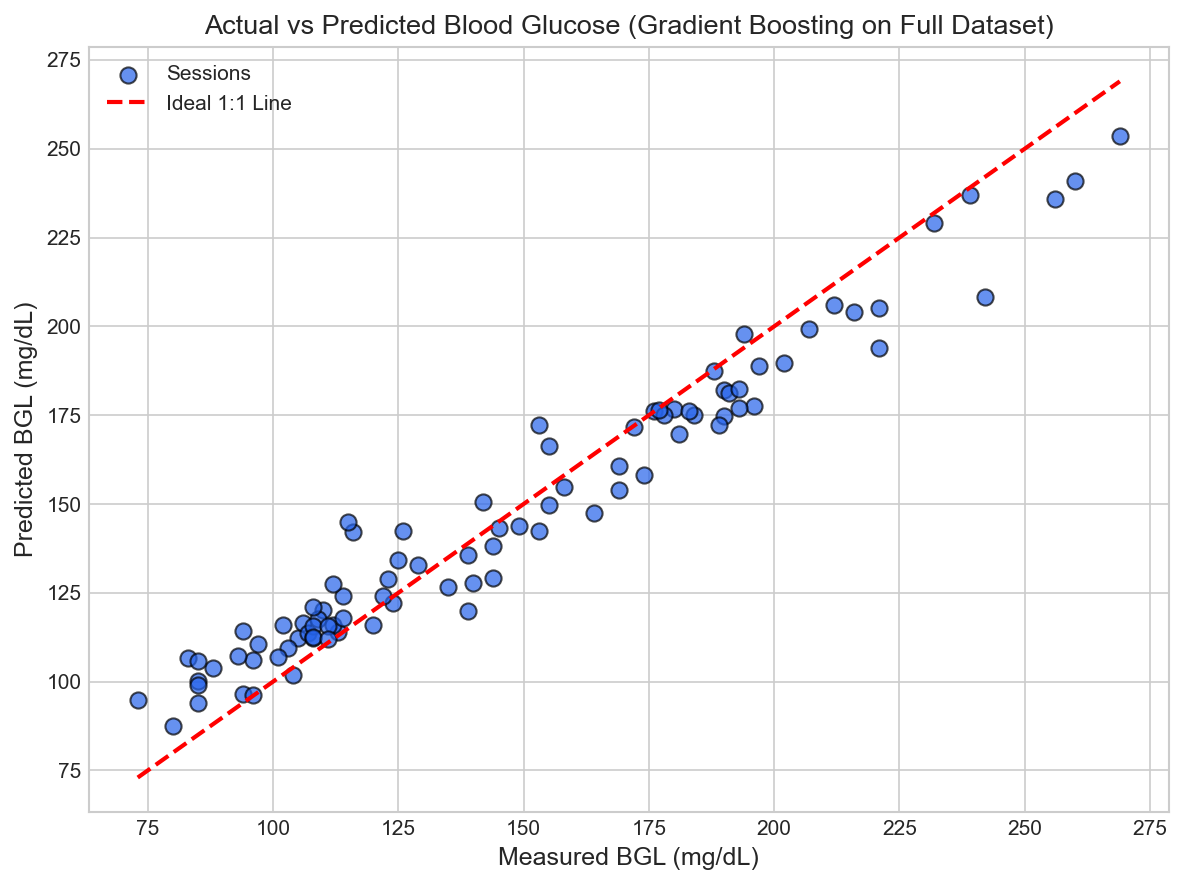

In [13]:
# Select final top 10 non-redundant features on full dataset
final_selected_features = select_features_on_fold_train(X_full_df, y, all_ppg_feature_names)
print(f"✓ Final Selected Features on Full Dataset ({len(final_selected_features)}): {final_selected_features}")

imp_final = SimpleImputer(strategy='mean')
X_final_imp = imp_final.fit_transform(X_full_df[final_selected_features])

full_dataset_results = []
trained_final_models = {}

for model_name, model in models.items():
    model.fit(X_final_imp, y)
    trained_final_models[model_name] = model
    
    preds = model.predict(X_final_imp)
    tr_mae = mean_absolute_error(y, preds)
    tr_rmse = np.sqrt(mean_squared_error(y, preds))
    tr_r2 = r2_score(y, preds)
    
    full_dataset_results.append({
        'Algorithm': model_name,
        'Full Dataset MAE (mg/dL)': f"{tr_mae:.2f}",
        'Full Dataset RMSE (mg/dL)': f"{tr_rmse:.2f}",
        'Full Dataset R^2': f"{tr_r2:.3f}"
    })

full_summary_df = pd.DataFrame(full_dataset_results)
print("\n=== Final Model Training Results (Full Dataset) ===")
display(full_summary_df)

# Plot Actual vs Predicted BGL for Best Model (Gradient Boosting / CatBoost)
best_model_name = 'Gradient Boosting'
best_preds = trained_final_models[best_model_name].predict(X_final_imp)

plt.figure(figsize=(8, 6))
plt.scatter(y, best_preds, alpha=0.7, color='#2563eb', edgecolors='k', s=60, label='Sessions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal 1:1 Line')
plt.xlabel('Measured BGL (mg/dL)', fontsize=12)
plt.ylabel('Predicted BGL (mg/dL)', fontsize=12)
plt.title(f'Actual vs Predicted Blood Glucose ({best_model_name} on Full Dataset)', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

# Subject-Grouped 90-10 Train-Test Split (Generalization Assessment)

To evaluate simple holdout generalization on unseen subjects, we perform a **subject-grouped 90-10 train-test split** (`GroupShuffleSplit`).
The holdout test set contains 10% of participants that are 100% unseen during training. Feature selection (`select_features_on_fold_train`) and imputer fitting are strictly isolated to the 90% training split to guarantee zero data leakage.

In [1]:
from sklearn.model_selection import GroupShuffleSplit

print("=== Subject-Grouped 90-10 Train-Test Split (Participant ID) ===")

# GroupShuffleSplit with 90-10 ratio (test_size=0.10) based on participant_id
gss = GroupShuffleSplit(n_splits=1, test_size=0.20)
train_idx, test_idx = next(gss.split(X_full_df, y, groups=groups))

X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
X_te_df, y_te = X_full_df.iloc[test_idx].copy(), y[test_idx]

train_participants = set(groups[train_idx])
test_participants = set(groups[test_idx])

print(f"✓ Total Sessions: Train={len(train_idx)} ({len(train_participants)} participants), Test={len(test_idx)} ({len(test_participants)} participants)")
print(f"✓ Test Participants (100% Unseen): {sorted(list(test_participants))}\n")

# Zero-Leakage Feature Selection on 90% Training Split ONLY
split_selected_feats = select_features_on_fold_train(X_tr_df, y_tr, all_ppg_feature_names, max_features=15)
print(f"✓ Selected Top Features on 90% Train Set ({len(split_selected_feats)}): {split_selected_feats}\n")

# Imputer fit strictly on Train set
imp_split = SimpleImputer(strategy='mean')
X_tr_imp = imp_split.fit_transform(X_tr_df[split_selected_feats])
X_te_imp = imp_split.transform(X_te_df[split_selected_feats])

holdout_results = []

for model_name, model in models.items():
    # Fit model on 90% Train split
    model.fit(X_tr_imp, y_tr)
    
    # Predict on 90% Train split
    tr_preds = model.predict(X_tr_imp)
    tr_mae = mean_absolute_error(y_tr, tr_preds)
    tr_rmse = np.sqrt(mean_squared_error(y_tr, tr_preds))
    tr_r2 = r2_score(y_tr, tr_preds)
    
    # Predict on 10% Unseen Test split
    te_preds = model.predict(X_te_imp)
    te_mae = mean_absolute_error(y_te, te_preds)
    te_rmse = np.sqrt(mean_squared_error(y_te, te_preds))
    te_r2 = r2_score(y_te, te_preds)
    
    holdout_results.append({
        'Algorithm': model_name,
        'Train (90%) MAE': f"{tr_mae:.2f}",
        'Train (90%) R^2': f"{tr_r2:.3f}",
        'Test (10% Unseen) MAE': f"{te_mae:.2f}",
        'Test (10% Unseen) RMSE': f"{te_rmse:.2f}",
        'Test (10% Unseen) R^2': f"{te_r2:.3f}"
    })

holdout_summary_df = pd.DataFrame(holdout_results)
print("=== 90-10 Subject-Grouped Train-Test Split Performance ===")
display(holdout_summary_df)

# Scatter Plot: Actual vs Predicted BGL on Unseen 10% Test Set for CatBoost / Best Model
best_test_model = 'CatBoost' if 'CatBoost' in models else 'Random Forest'
best_model_obj = models[best_test_model]
te_preds_best = best_model_obj.predict(X_te_imp)

plt.figure(figsize=(7, 5))
plt.scatter(y_te, te_preds_best, color='#059669', edgecolors='k', s=70, label='Unseen Test Sessions')
plt.plot([min(y_tr.min(), y_te.min()), max(y_tr.max(), y_te.max())], 
         [min(y_tr.min(), y_te.min()), max(y_tr.max(), y_te.max())], 'r--', lw=2, label='Ideal 1:1 Line')
plt.xlabel('Actual BGL (mg/dL)', fontsize=12)
plt.ylabel('Predicted BGL (mg/dL)', fontsize=12)
plt.title(f'90-10 Holdout Test: Actual vs Predicted BGL ({best_test_model})', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()


=== Subject-Grouped 90-10 Train-Test Split (Participant ID) ===


NameError: name 'X_full_df' is not defined